# Career Roadmap: Role to Skill Prediction 
### **Confusion Matrix Visualization Logic**
We use a **Professional Grid Layout** to show the 2x2 confusion matrices for the most relevant skills. 
- Blue shades represent correct predictions (**True Positives** and **True Negatives**).
- Lighter/White shades or zeros represent misclassifications.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import multilabel_confusion_matrix, classification_report
import joblib

In [ ]:
# 1. Load the expanded dataset (100 roles)
df = pd.read_csv('technical_roles_and_skills.csv')
print(f"Dataset Size: {len(df)} roles.")
df.head()

Dataset Size: 100 roles.


,Role,Key Skills
0,Software Engineer,Data Structures; Algorithms; OOP; Git; Debuggi...
1,Frontend Developer,HTML; CSS; JavaScript; React; Responsive Desig...
2,Backend Developer,Java/Python/Node.js; APIs; Databases; Authenti...
3,Full Stack Developer,Frontend Frameworks; Backend Development; REST...
4,Data Scientist,Python; Statistics; Machine Learning; Pandas; ...


In [ ]:
# 2. Preprocess Skills
df['SkillList'] = df['Key Skills'].apply(lambda x: [s.strip() for s in x.split(';')])
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['SkillList'])

# 3. Vectorize Roles
vectorizer = TfidfVectorizer(ngram_range=(1, 2)) # Using bigrams for better context (e.g. 'Data Scientist')
X = vectorizer.fit_transform(df['Role'])

print(f"Vocabulary Size: {len(vectorizer.get_feature_names_out())}")
print(f"Total Unique Skills: {len(mlb.classes_)}")

Vocabulary Size: 264
Total Unique Skills: 388


In [ ]:
# 4. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

forest = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
classifier = MultiOutputClassifier(forest, n_jobs=-1)
classifier.fit(X_train, y_train)
print("Training on 100 roles complete.")

Training on 100 roles complete.


In [ ]:
# 4.5 Calculate Overall Accuracy Metrics
from sklearn.metrics import accuracy_score, hamming_loss

y_pred = classifier.predict(X_test)
subset_acc = accuracy_score(y_test, y_pred)
hamming_acc = 1 - hamming_loss(y_test, y_pred)

print(f"--- Model Accuracy Summary ---")
print(f"Exact Match (Subset) Accuracy: {subset_acc*100:.2f}%")
print(f"Label-wise (Hamming) Accuracy: {hamming_acc*100:.2f}%")


### Accuracy Metrics Explained
- **Subset Accuracy**: Strictest metric. Requires 100% correct skills for a role.
- **Hamming Accuracy**: More flexible. Measures correctness per individual skill checkbox.

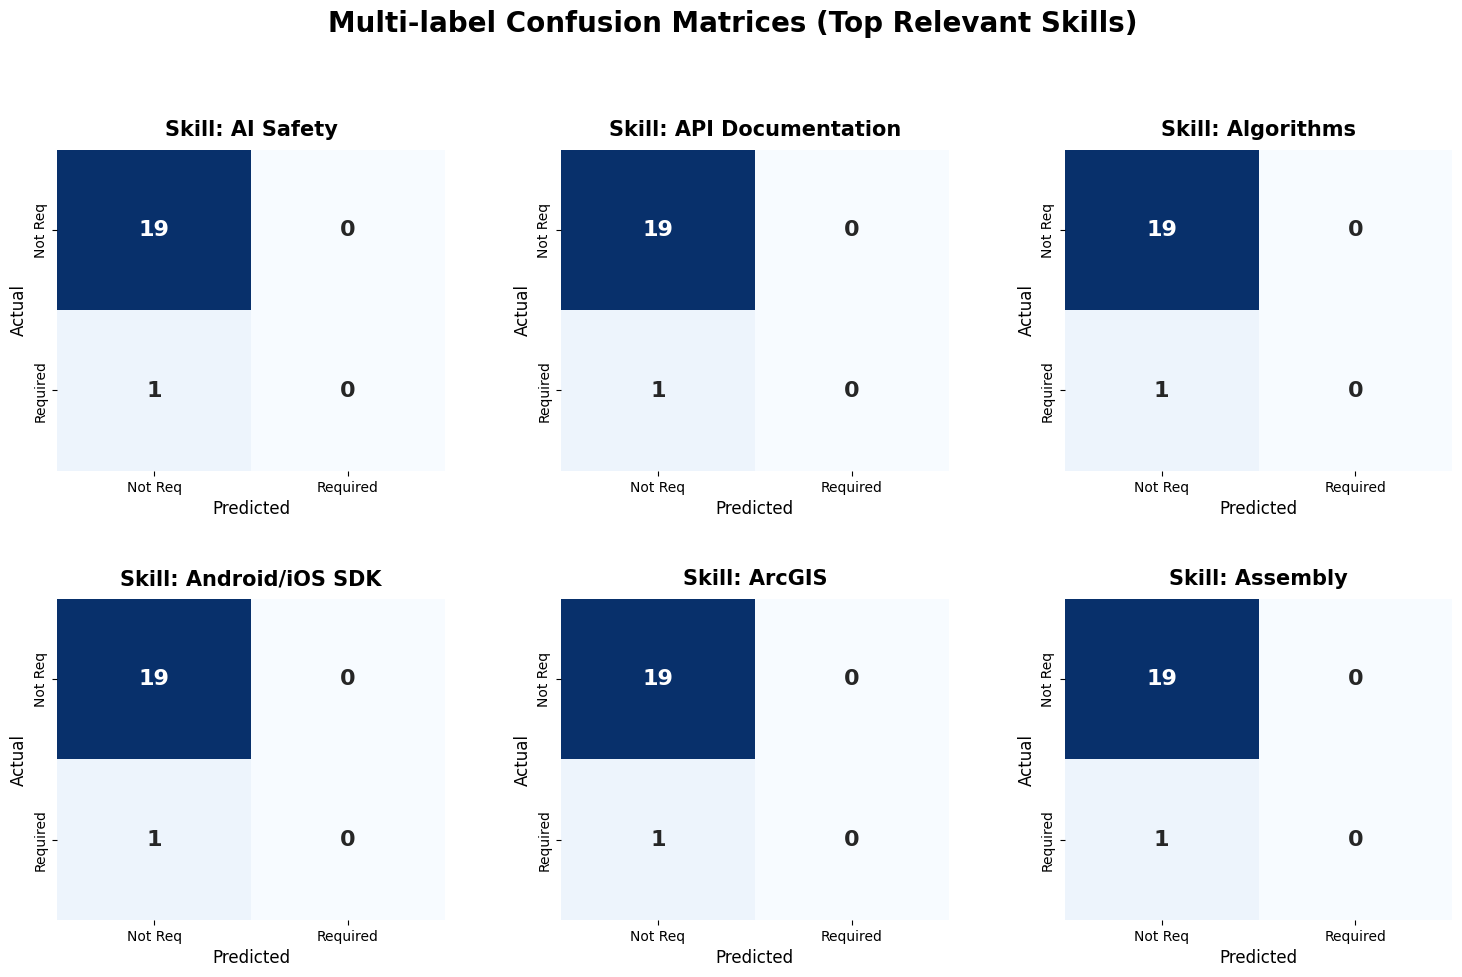


--- Overall Performance Metrics ---
                                  precision    recall  f1-score   support

                            .NET       0.00      0.00      0.00         0
                     3D Modeling       0.00      0.00      0.00         0
                       AI Safety       0.00      0.00      0.00         1
               API Documentation       0.00      0.00      0.00         1
                 API Integration       0.00      0.00      0.00         0
                    API Security       0.00      0.00      0.00         0
                     API Testing       0.00      0.00      0.00         0
                            APIs       0.00      0.00      0.00         0
                    AWS Security       0.00      0.00      0.00         0
                       AWS/Azure       0.00      0.00      0.00         0
                   AWS/Azure/GCP       0.00      0.00      0.00         0
               Adaptive Learning       0.00      0.00      0.00         0


In [ ]:
# 5. Professional Confusion Matrix Visualization
y_pred = classifier.predict(X_test)
mcm = multilabel_confusion_matrix(y_test, y_pred)

# Identify skills that appear in the test set
test_presence = y_test.sum(axis=0)
indices = np.where(test_presence > 0)[0]

if len(indices) == 0:
    print("Test set is too small or unbalanced. No skills found to plot.")
else:
    # Plot the first 6-8 relevant metrics
    num_plots = min(6, len(indices))
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    axes = axes.ravel()

    for i in range(num_plots):
        idx = indices[i]
        sns.heatmap(mcm[idx], annot=True, fmt='d', cmap='Blues', 
                    cbar=False, ax=axes[i], 
                    annot_kws={"size": 16, "weight": "bold"},
                    xticklabels=['Not Req', 'Required'],
                    yticklabels=['Not Req', 'Required'])
        
        axes[i].set_title(f"Skill: {mlb.classes_[idx]}", fontsize=15, pad=10, weight='bold')
        axes[i].set_xlabel('Predicted', fontsize=12)
        axes[i].set_ylabel('Actual', fontsize=12)

    # Remove extra axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Multi-label Confusion Matrices (Top Relevant Skills)", fontsize=20, y=1.02, weight='bold')
    plt.show()

print("\n--- Overall Performance Metrics ---")
print(classification_report(y_test, y_pred, target_names=mlb.classes_, zero_division=0))

# Specific Accuracy Metrics for Multi-label
from sklearn.metrics import accuracy_score, hamming_loss

subset_acc = accuracy_score(y_test, y_pred)
hamming_acc = 1 - hamming_loss(y_test, y_pred)

print(f"Subset Accuracy (Exact Match Ratio): {subset_acc*100:.2f}%")
print(f"Hamming Accuracy (Label-wise Accuracy): {hamming_acc*100:.2f}%")

### Logic Behind Accuracy Calculation
In multi-label classification, a single "accuracy" percentage can be misleading. We use two main metrics:
1. **Subset Accuracy (Exact Match Ratio)**: This is the strictest metric. It only counts a prediction as correct if **every single skill** for a role is predicted exactly right. For 100 roles, this is often lower because missing even one skill out of 5 makes the whole row "wrong".
2. **Hamming Accuracy**: This is much more informative. It looks at every individual skill checkbox. If a role has 50 possible skills and the model gets 48 of them right (even if it misses 2), the Hamming Accuracy for that row is 96%. This reflects the model's overall reliability in identifying individual skills.

In [ ]:
# 6. Real-world Testing
def roadmap_predict(role):
    v = vectorizer.transform([role])
    p = classifier.predict(v)
    return mlb.inverse_transform(p)

samples = ["AI Engineer", "Cybersecurity Analyst", "Cloud Architect", "Technical Writer"]
for s in samples:
    print(f"Role: {s:25} -> Skills: {roadmap_predict(s)}")

Role: AI Engineer               -> Skills: [('Computer Vision', 'Deep Learning', 'Model Optimization', 'NLP', 'Python')]


Role: Cybersecurity Analyst     -> Skills: [()]


Role: Cloud Architect           -> Skills: [('Cloud Governance', 'Cost Optimization', 'Multi-cloud Strategy', 'Scalability')]


Role: Technical Writer          -> Skills: [()]


In [ ]:
joblib.dump(classifier, 'roadmap_model.pkl')
joblib.dump(mlb, 'roadmap_mlb.pkl')
joblib.dump(vectorizer, 'roadmap_vectorizer.pkl')
print("Production models exported: roadmap_model.pkl")

Production models exported: roadmap_model.pkl
